# Online readiness model (v2)

**Question:** among active cards that have **never paid online** so far, which ones will make an online card
purchase in the **next 3 months**, and which behaviours predict it?

**What is new in v2**
1. **Rolling backtest** on four snapshots (every 3 months), each predicted only with models trained on earlier data.
2. **Hyper-parameter tuning** with time-based validation (the model never sees the future).
3. **Probability calibration** on a separate period, so "20%" really means about 20%.
4. **Personas** (KMeans on in-store behaviour) computed in the same pipeline, and the readiness score shown per persona.

**Snapshots** (month index, Jan 2025 = 0). Features use the 6 months before T, the label the 3 months from T:

| T | Snapshot | Feature window | Label window | Role |
|---|---|---|---|---|
| 6 | Jul 2025 | Jan-Jun 2025 | Jul-Sep 2025 | train |
| 9 | Oct 2025 | Apr-Sep 2025 | Oct-Dec 2025 | train / validation |
| 12 | Jan 2026 | Jul-Dec 2025 | Jan-Mar 2026 | validation / calibration |
| 15 | Apr 2026 | Oct 2025-Mar 2026 | Apr-Jun 2026 | **final test** |

A model evaluated on snapshot T is trained only on snapshots whose label window ends before T.

Population per snapshot: cards with **no online purchase in any month before T** (since Jan 2025), at least
3 active months and 20 transactions in the feature window, and active in the label window.
Label: at least one online purchase in the label window.

Inputs: `cache/card_month_panel`, `cache/card_first_online`, `cache/slim` (built by `wallet_online.ipynb`).
The model works on single cards internally; everything shown is aggregated to groups of at least 30 cards.

In [1]:
import itertools
from pathlib import Path

import duckdb
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from paths import CACHE, DATA
PANEL = (CACHE / "card_month_panel").as_posix()
FIRST_ONLINE = (CACHE / "card_first_online").as_posix()
SLIM = (CACHE / "slim").as_posix()
FEATURES = CACHE / "readiness_features_v2"  # one parquet file per snapshot
SLIM_PARTS = CACHE / "readiness_slim_parts"  # per snapshot x bucket, written straight to disk
N_BUCKETS = 16
MIN_CARDS = 30
SNAPSHOTS = [6, 9, 12, 15]
FINAL_T = 15
RNG = 42

con = duckdb.connect()
con.sql("SET memory_limit = '2GB'")
con.sql("SET threads = 4")
con.sql("SET preserve_insertion_order = false")
con.sql(f"CREATE OR REPLACE VIEW panel AS SELECT *, (month // 100 - 2025) * 12 + month % 100 - 1 AS m FROM read_parquet('{PANEL}/*.parquet')")
con.sql(f"CREATE OR REPLACE VIEW attrs AS SELECT card, card_type, home_fua FROM read_parquet('{FIRST_ONLINE}/*.parquet')")

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})
pct = mtick.PercentFormatter(100)

def safe(df, cards_col="cards"):
    return df[df[cards_col] >= MIN_CARDS].copy()

def yyyymm(m):
    return (2025 + m // 12) * 100 + m % 12 + 1

MONTH_NAMES = {t: pd.Timestamp(year=2025 + t // 12, month=t % 12 + 1, day=1).strftime("%b %Y") for t in range(18)}

NOT_SHOPPING_MCC = "(4829, 6012, 6051, 6211, 6538, 6540)"
MACRO = '''
CASE
  WHEN mrch_catg_cd IN (5411, 5422, 5441, 5451, 5462, 5499, 5921) THEN 'grocery'
  WHEN mrch_catg_cd IN (5812, 5813) THEN 'restaurants_bars'
  WHEN mrch_catg_cd = 5814 THEN 'fast_food'
  WHEN mrch_catg_cd IN (5541, 5542, 5983, 7523, 7538, 5533, 4784, 7542) THEN 'car_fuel'
  WHEN mrch_catg_cd = 4121 THEN 'taxi'
  WHEN mrch_catg_cd IN (4111, 4112, 4131, 4789, 4011, 4411) THEN 'public_transport'
  WHEN mrch_catg_cd BETWEEN 3000 AND 3999 OR mrch_catg_cd IN (4511, 4722, 7011, 7512, 4582) THEN 'travel'
  WHEN mrch_catg_cd BETWEEN 5611 AND 5699 OR mrch_catg_cd IN (5941, 5655, 5661, 5139, 5137) THEN 'fashion_sport'
  WHEN mrch_catg_cd BETWEEN 5712 AND 5734 OR mrch_catg_cd IN (5200, 5211, 5231, 5251, 5261, 5065, 5946, 5045) THEN 'home_electronics'
  WHEN mrch_catg_cd IN (5912, 5977, 5122, 7230, 7298, 5975, 5976) OR mrch_catg_cd BETWEEN 8011 AND 8099 THEN 'health_beauty'
  WHEN mrch_catg_cd IN (5815, 5816, 5817, 5818, 4899, 7372, 5735) THEN 'digital_content'
  WHEN mrch_catg_cd IN (4812, 4814, 4900, 6300, 8220, 8299, 8211, 8241, 8244, 8249) THEN 'bills_telecom_edu'
  WHEN mrch_catg_cd IN (7832, 7922, 7929, 7991, 7996, 7997, 7999, 7941, 7995, 7932, 7933) THEN 'entertainment_betting'
  WHEN mrch_catg_cd IN (5262, 5399, 5311, 5310, 5300, 5331, 5964, 5969) THEN 'marketplace_general'
  WHEN mrch_catg_cd IN (5942, 5943, 5945, 5947, 5992, 5994, 5995, 5970, 5949, 5944) THEN 'hobby_books_gifts'
  ELSE 'other'
END
'''
GROUPS = ["grocery", "restaurants_bars", "fast_food", "car_fuel", "taxi", "public_transport", "travel",
          "fashion_sport", "home_electronics", "health_beauty", "digital_content", "bills_telecom_edu",
          "entertainment_betting", "marketplace_general", "hobby_books_gifts", "other"]

## Build features for all snapshots (cached)

In [2]:
if not FEATURES.exists():
    SLIM_PARTS.mkdir(exist_ok=True)
    local_hour = "((ts % 1000000) // 10000 + CASE WHEN month % 100 BETWEEN 4 AND 10 THEN 2 ELSE 1 END) % 24"
    day = "make_date(CAST(ts // 10000000000 AS INT), CAST(ts // 100000000 % 100 AS INT), CAST(ts // 1000000 % 100 AS INT))"
    shares = ", ".join(f"avg(CAST(({MACRO}) = '{g}' AS DOUBLE)) FILTER (WHERE cp_flag = 1) AS s_{g}" for g in GROUPS)
    # Transaction-level in-store features, one small query per snapshot and bucket, written to disk
    for t in SNAPSHOTS:
        for b in range(N_BUCKETS):
            out = SLIM_PARTS / f"t{t:02d}_b{b:02d}.parquet"
            if out.exists():
                continue
            con.sql(f'''
                COPY (
                    SELECT card, {t} AS snapshot,
                           count(DISTINCT mrch_catg_cd) FILTER (WHERE cp_flag = 1) AS n_store_categories,
                           avg(({local_hour} >= 19)::INT) FILTER (WHERE cp_flag = 1) AS evening_share,
                           avg((dayofweek({day}) IN (0, 6))::INT) FILTER (WHERE cp_flag = 1) AS weekend_share,
                           avg((NOT merchant_pl)::INT) FILTER (WHERE cp_flag = 1) AS abroad_share,
                           exp(avg(ln(1 + greatest(amt, 0))) FILTER (WHERE cp_flag = 1)) - 1 AS typical_store_amount,
                           {shares}
                    FROM read_parquet('{SLIM}/bucket={b}/*.parquet')
                    WHERE month BETWEEN {yyyymm(t - 6)} AND {yyyymm(t - 1)}
                    GROUP BY card
                ) TO '{out.as_posix()}' (FORMAT parquet)
            ''')
    con.sql(f"CREATE OR REPLACE VIEW slim_feat AS SELECT * FROM read_parquet('{SLIM_PARTS.as_posix()}/*.parquet')")

    TOP_FUAS = con.sql('''
        SELECT home_fua FROM attrs WHERE home_fua IS NOT NULL GROUP BY 1 ORDER BY count(*) DESC LIMIT 15
    ''').df().home_fua.tolist()
    fua_list = ", ".join(f"'{f}'" for f in TOP_FUAS)

    FEATURES.mkdir(exist_ok=True)

    def snapshot(t):
        con.sql(f'''
          COPY (
            WITH hist AS (
                SELECT card, sum(n_online) AS online_before, min(m) AS first_m,
                       min(m) FILTER (WHERE n_wallet_store > 0) AS first_wallet_m
                FROM panel WHERE m < {t} GROUP BY card
            ),
            win AS (
                SELECT card,
                       count(*) AS active_months,
                       sum(n_tx) AS n_tx,
                       sum(n_store) AS n_store,
                       sum(n_wallet_store) AS n_wallet,
                       sum(n_tx - n_store - n_online) AS n_cnp_other,
                       sum(n_tx) FILTER (WHERE m >= {t} - 3) AS n_tx_last3,
                       sum(n_wallet_store) FILTER (WHERE m >= {t} - 3) AS n_wallet_last3,
                       sum(n_store) FILTER (WHERE m >= {t} - 3) AS n_store_last3
                FROM panel WHERE m BETWEEN {t} - 6 AND {t} - 1 GROUP BY card
            ),
            lab AS (
                SELECT card, sum(n_online) > 0 AS label FROM panel WHERE m BETWEEN {t} AND {t} + 2 GROUP BY card
            )
            SELECT w.card, {t} AS snapshot,
                   w.active_months,
                   w.n_tx / w.active_months AS tx_per_month,
                   coalesce(w.n_tx_last3, 0) / nullif(w.n_tx - coalesce(w.n_tx_last3, 0), 0) AS tx_trend,
                   w.n_wallet / nullif(w.n_store, 0) AS wallet_share,
                   coalesce(w.n_wallet_last3, 0) / nullif(w.n_store_last3, 0) AS wallet_share_last3,
                   (h.first_wallet_m IS NOT NULL)::INT AS wallet_ever,
                   {t} - h.first_wallet_m AS months_since_first_wallet,
                   CASE WHEN h.first_m = 0 THEN 99 ELSE {t} - h.first_m END AS card_age_months,
                   w.n_cnp_other / w.n_tx AS cnp_other_share,
                   a.card_type,
                   CASE WHEN a.home_fua IS NULL THEN 'UNKNOWN'
                        WHEN a.home_fua IN ({fua_list}) THEN a.home_fua ELSE 'OTHER' END AS home_area,
                   f.* EXCLUDE (card, snapshot),
                   l.label::INT AS label
            FROM win w
            JOIN hist h USING (card)
            JOIN lab l USING (card)
            LEFT JOIN attrs a USING (card)
            LEFT JOIN slim_feat f ON f.card = w.card AND f.snapshot = {t}
            WHERE h.online_before = 0 AND w.active_months >= 3 AND w.n_tx >= 20
          ) TO '{(FEATURES / f"t{t:02d}.parquet").as_posix()}' (FORMAT parquet)
        ''')

    for t in SNAPSHOTS:
        snapshot(t)

# Load with 32-bit floats to save memory
data = pd.read_parquet(FEATURES)
for c in data.select_dtypes("float64").columns:
    data[c] = data[c].astype("float32")
data = data.drop(columns=["card"]).assign(card=pd.read_parquet(FEATURES, columns=["card"]).card.values)
data.groupby("snapshot").agg(cards=("label", "size"), start_rate=("label", "mean")).rename(index=MONTH_NAMES)

,cards,start_rate
snapshot,,
Jul 2025,303628,0.076
Oct 2025,292323,0.062
Jan 2026,278125,0.052
Apr 2026,265324,0.049
18,274209,NaN


In [3]:
NUM = ["active_months", "tx_per_month", "tx_trend", "wallet_share", "wallet_share_last3", "wallet_ever",
       "months_since_first_wallet", "card_age_months", "cnp_other_share", "n_store_categories",
       "evening_share", "weekend_share", "abroad_share", "typical_store_amount"] + [f"s_{g}" for g in GROUPS]
CAT = ["card_type", "home_area"]
CATEGORIES = {c: sorted(data[c].fillna("UNKNOWN").unique()) for c in CAT}

def X_of(d):
    X = d[NUM + CAT].copy()
    for c in CAT:
        X[c] = pd.Categorical(X[c].fillna("UNKNOWN"), categories=CATEGORIES[c])
    return X

def part(ts):
    d = data[data.snapshot.isin(ts)]
    return X_of(d), d.label.values

def lift_at(y, p, top=0.1):
    k = max(int(len(p) * top), 1)
    return y[np.argsort(-p)[:k]].mean() / y.mean()

def metrics(y, p):
    return {"AUC": roc_auc_score(y, p), "PR-AUC": average_precision_score(y, p),
            "lift top 10%": lift_at(y, p, 0.1), "lift top 20%": lift_at(y, p, 0.2)}

def train_before(t):
    # snapshots whose label window (s ... s+2) ends before t
    return [s for s in SNAPSHOTS if s + 2 < t]

## 1. Hyper-parameter tuning with time-based validation

Folds: train on Jul 2025 -> validate on Oct 2025; train on Jul + Oct 2025 -> validate on Jan 2026.
The final test snapshot (Apr 2026) is not used here.

In [4]:
FOLDS = [(train_before(9), 9), (train_before(12), 12)]
grid = {"num_leaves": [15, 31, 63], "min_child_samples": [100, 400], "learning_rate": [0.03, 0.06],
        "n_estimators": [300, 600]}
rows = []
for values in itertools.product(*grid.values()):
    params = dict(zip(grid.keys(), values))
    aucs = []
    for tr_ts, va_t in FOLDS:
        Xtr, ytr = part(tr_ts)
        Xva, yva = part([va_t])
        m = lgb.LGBMClassifier(**params, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                               random_state=RNG, verbose=-1).fit(Xtr, ytr, categorical_feature=CAT)
        aucs.append(roc_auc_score(yva, m.predict_proba(Xva)[:, 1]))
    rows.append({**params, "auc_oct25": aucs[0], "auc_jan26": aucs[1], "auc_mean": np.mean(aucs)})
tuning = pd.DataFrame(rows).sort_values("auc_mean", ascending=False)
BEST = {k: (int(v) if k != "learning_rate" else float(v)) for k, v in tuning.iloc[0][list(grid)].items()}
print("best params:", BEST)
tuning.head(8)

best params: {'num_leaves': 31, 'min_child_samples': 400, 'learning_rate': 0.03, 'n_estimators': 300}


,num_leaves,min_child_samples,learning_rate,n_estimators,auc_oct25,auc_jan26,auc_mean
12,31,400,0.030,300,0.736,0.742,0.739
8,31,100,0.030,300,0.735,0.742,0.739
1,15,100,0.030,600,0.735,0.742,0.739
5,15,400,0.030,600,0.735,0.742,0.738
6,15,400,0.060,300,0.735,0.741,0.738
0,15,100,0.030,300,0.736,0.741,0.738
16,63,100,0.030,300,0.735,0.742,0.738
20,63,400,0.030,300,0.735,0.742,0.738


## 2. Rolling backtest: every snapshot predicted from the past only

Compared with two baselines: a one-line rule (share of in-store payments made by phone) and logistic regression.

,test snapshot,trained on,model,cards,start rate,AUC,PR-AUC,lift top 10%,lift top 20%
0,Oct 2025,Jul 2025,rule: wallet share,292323,0.062,0.615,0.102,2.836,1.979
1,Oct 2025,Jul 2025,logistic regression,292323,0.062,0.722,0.154,2.999,2.391
2,Oct 2025,Jul 2025,LightGBM (tuned),292323,0.062,0.736,0.168,3.167,2.468
3,Jan 2026,"Jul 2025, Oct 2025",rule: wallet share,278125,0.052,0.616,0.087,2.913,1.986
4,Jan 2026,"Jul 2025, Oct 2025",logistic regression,278125,0.052,0.727,0.143,3.139,2.436
5,Jan 2026,"Jul 2025, Oct 2025",LightGBM (tuned),278125,0.052,0.742,0.156,3.322,2.537
6,Apr 2026,"Jul 2025, Oct 2025, Jan 2026",rule: wallet share,265324,0.049,0.629,0.088,3.101,2.106
7,Apr 2026,"Jul 2025, Oct 2025, Jan 2026",logistic regression,265324,0.049,0.739,0.146,3.324,2.578
8,Apr 2026,"Jul 2025, Oct 2025, Jan 2026",LightGBM (tuned),265324,0.049,0.757,0.162,3.547,2.703


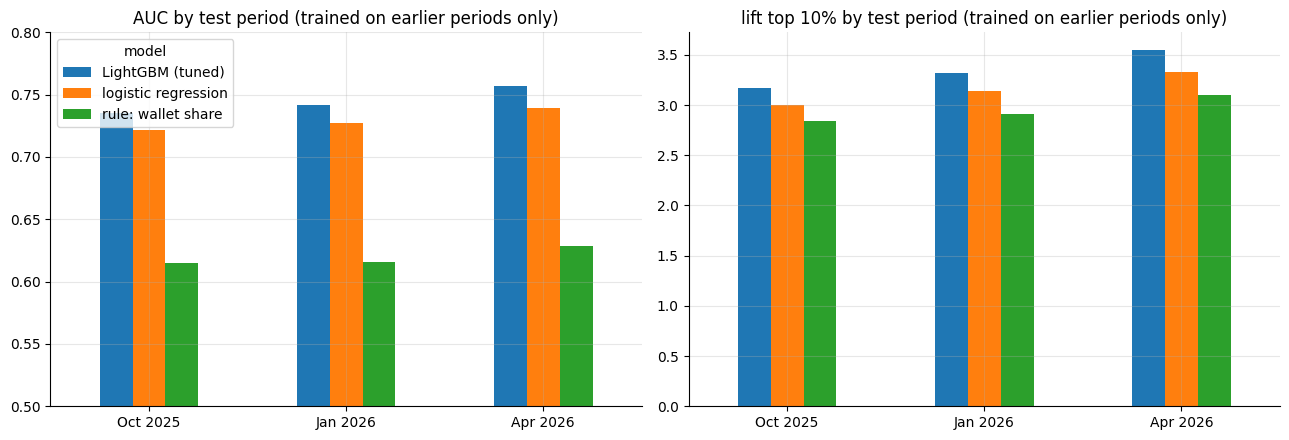

In [5]:
def fit_gbm(ts):
    X, y = part(ts)
    return lgb.LGBMClassifier(**BEST, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                              random_state=RNG, verbose=-1).fit(X, y, categorical_feature=CAT)

def fit_logit(ts):
    X, y = part(ts)
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(X[NUM].fillna(0), y)

bt = []
for t in [9, 12, 15]:
    tr_ts = train_before(t)
    Xte, yte = part([t])
    preds = {
        "rule: wallet share": Xte.wallet_share.fillna(0).values,
        "logistic regression": fit_logit(tr_ts).predict_proba(Xte[NUM].fillna(0))[:, 1],
        "LightGBM (tuned)": fit_gbm(tr_ts).predict_proba(Xte)[:, 1],
    }
    for name, p in preds.items():
        bt.append({"test snapshot": MONTH_NAMES[t], "trained on": ", ".join(MONTH_NAMES[s] for s in tr_ts),
                   "model": name, "cards": len(yte), "start rate": yte.mean(), **metrics(yte, p)})
backtest = pd.DataFrame(bt)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col in zip(axes, ["AUC", "lift top 10%"]):
    piv = backtest.pivot(index="test snapshot", columns="model", values=col).loc[[MONTH_NAMES[t] for t in [9, 12, 15]]]
    piv.plot.bar(ax=ax, rot=0)
    ax.set_title(f"{col} by test period (trained on earlier periods only)")
    ax.set_xlabel("")
    if col == "AUC":
        ax.set_ylim(0.5, 0.8)
axes[1].legend().remove()
plt.tight_layout()
backtest

## 3. Final model and calibration

- Train on Jul + Oct 2025, **calibrate** (isotonic regression) on Jan 2026, **test** on Apr 2026.
- Calibration does not change the ranking (AUC), only makes the probabilities trustworthy, which matters for
  estimating how many customers a campaign can reach.

In [6]:
final = fit_gbm([6, 9])
Xcal, ycal = part([12])
iso = IsotonicRegression(out_of_bounds="clip").fit(final.predict_proba(Xcal)[:, 1], ycal)

test = data[data.snapshot == FINAL_T].reset_index(drop=True)
Xte, yte = X_of(test), test.label.values
p_raw = final.predict_proba(Xte)[:, 1]
p_cal = iso.predict(p_raw)

final_metrics = pd.DataFrame([
    {"version": "raw", **metrics(yte, p_raw), "Brier": brier_score_loss(yte, p_raw), "mean predicted": p_raw.mean()},
    {"version": "calibrated", **metrics(yte, p_cal), "Brier": brier_score_loss(yte, p_cal), "mean predicted": p_cal.mean()},
])
print(f"final test ({MONTH_NAMES[FINAL_T]}): {len(yte):,} cards, actual start rate {yte.mean():.2%}")
final_metrics

final test (Apr 2026): 265,324 cards, actual start rate 4.92%


,version,AUC,PR-AUC,lift top 10%,lift top 20%,Brier,mean predicted
0,raw,0.756,0.160,3.545,2.690,0.044,0.060
1,calibrated,0.756,0.155,3.540,2.689,0.044,0.047


,cards,raw,calibrated,actual
decile,,,,
10,26533,0.192,0.163,0.174
9,26532,0.106,0.084,0.091
8,26532,0.075,0.060,0.060
7,26533,0.058,0.045,0.046
6,26532,0.046,0.036,0.036
5,26532,0.037,0.027,0.028
4,26533,0.030,0.021,0.021
3,26532,0.024,0.017,0.017
2,26532,0.018,0.013,0.012


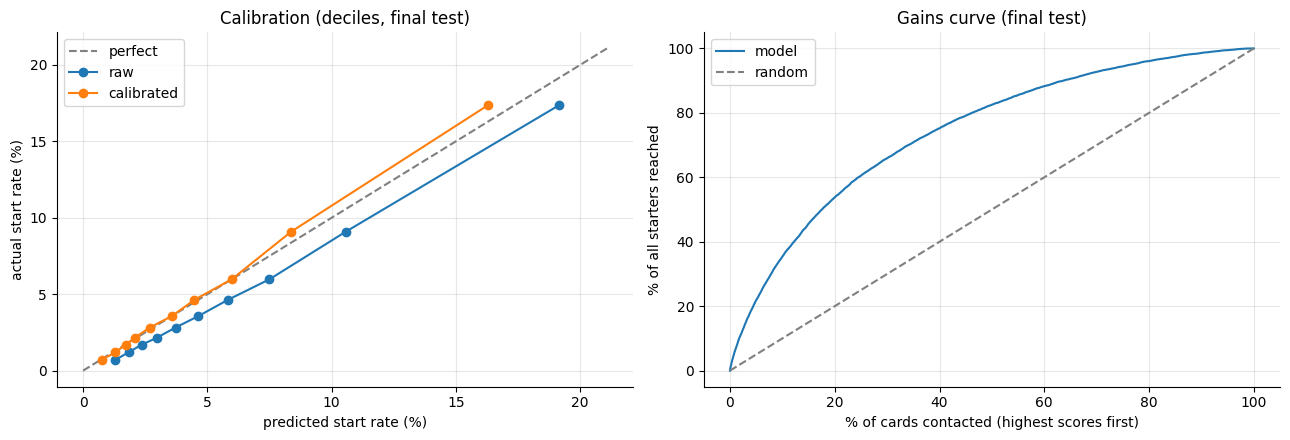

In [7]:
# Reliability: predicted vs actual by decile of predicted probability
rel = pd.DataFrame({"raw": p_raw, "cal": p_cal, "y": yte})
rel["decile"] = pd.qcut(rel.cal.rank(method="first"), 10, labels=False) + 1
r = rel.groupby("decile").agg(cards=("y", "size"), raw=("raw", "mean"), calibrated=("cal", "mean"), actual=("y", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
lim = r[["raw", "calibrated", "actual"]].values.max() * 100 * 1.1
axes[0].plot([0, lim], [0, lim], color="grey", ls="--", label="perfect")
axes[0].plot(r.raw * 100, r.actual * 100, "o-", label="raw")
axes[0].plot(r.calibrated * 100, r.actual * 100, "o-", label="calibrated")
axes[0].set_xlabel("predicted start rate (%)")
axes[0].set_ylabel("actual start rate (%)")
axes[0].set_title("Calibration (deciles, final test)")
axes[0].legend()

order = np.argsort(-p_cal)
cum = np.cumsum(yte[order]) / yte.sum() * 100
x = np.arange(1, len(yte) + 1) / len(yte) * 100
axes[1].plot(x, cum, label="model")
axes[1].plot([0, 100], [0, 100], color="grey", ls="--", label="random")
axes[1].set_xlabel("% of cards contacted (highest scores first)")
axes[1].set_ylabel("% of all starters reached")
axes[1].set_title("Gains curve (final test)")
axes[1].legend()
plt.tight_layout()
r.sort_index(ascending=False)

## 4. Which behaviours drive the prediction? (SHAP, final test)

,mean_abs_shap,direction
evening_share,0.233,higher -> more likely
s_fast_food,0.229,higher -> more likely
s_car_fuel,0.110,higher -> more likely
wallet_ever,0.099,higher -> more likely
s_restaurants_bars,0.094,higher -> more likely
wallet_share,0.089,higher -> more likely
typical_store_amount,0.079,higher -> less likely
s_public_transport,0.056,higher -> more likely
abroad_share,0.056,higher -> more likely
s_entertainment_betting,0.051,higher -> more likely


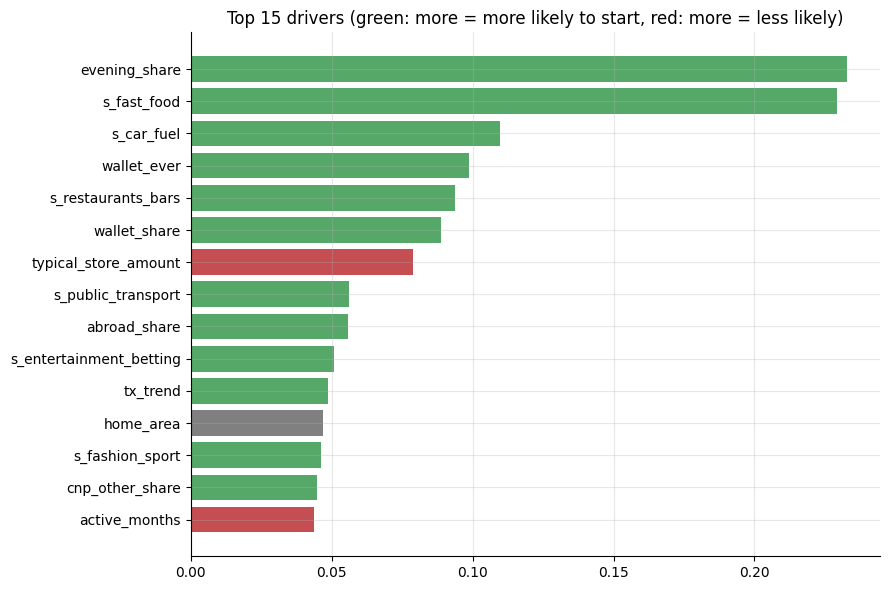

In [8]:
contrib = final.booster_.predict(Xte, pred_contrib=True)
shap_df = pd.DataFrame(contrib[:, :-1], columns=Xte.columns)
imp = shap_df.abs().mean().sort_values(ascending=False)

# Direction: correlation between feature value and its SHAP contribution (numeric features)
direction = {c: np.corrcoef(Xte[c].fillna(0), shap_df[c])[0, 1] if c in NUM and Xte[c].fillna(0).std() > 0 else np.nan
             for c in imp.index}
top = imp.head(15).to_frame("mean_abs_shap")
top["direction"] = [("higher -> more likely" if direction[c] > 0.1 else "higher -> less likely" if direction[c] < -0.1
                     else "mixed / categorical") for c in top.index]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#55a868" if d.startswith("higher -> more") else "#c44e52" if d.startswith("higher -> less") else "grey"
          for d in top.direction]
ax.barh(top.index[::-1], top.mean_abs_shap[::-1], color=colors[::-1])
ax.set_title("Top 15 drivers (green: more = more likely to start, red: more = less likely)")
plt.tight_layout()
top

## 5. Personas x readiness

KMeans (k = 6) on in-store behaviour, fitted on the Jul 2025 snapshot and applied to the final test snapshot.
For each persona: size, actual start rate, and how concentrated the model's top 10% is inside it.

In [9]:
CLUSTER_FEATURES = ["wallet_share", "evening_share", "weekend_share", "abroad_share", "n_store_categories"] + \
                   [f"s_{g}" for g in GROUPS]

def cmat(d):
    X = d[CLUSTER_FEATURES].fillna(0).copy()
    X["log_tx_per_month"] = np.log1p(d.tx_per_month)
    X["log_median_amount"] = np.log1p(d.typical_store_amount.fillna(0))
    return X

fit_on = data[data.snapshot == 6]
scaler = StandardScaler().fit(cmat(fit_on))
km = KMeans(n_clusters=6, n_init=10, random_state=RNG).fit(scaler.transform(cmat(fit_on)))
test["persona_id"] = km.predict(scaler.transform(cmat(test)))

# Name personas with explicit rules on their profile relative to the average card (first matching rule wins)
prof = test.groupby("persona_id")[CLUSTER_FEATURES + ["tx_per_month"]].mean()
ratio = prof / test[CLUSTER_FEATURES + ["tx_per_month"]].mean()
RULES = [
    ("travellers", lambda r: r.abroad_share > 5),
    ("phone-first city", lambda r: r.wallet_share > 3),
    ("home & car", lambda r: r.s_car_fuel > 2 and r.s_home_electronics > 2),
    ("mall shoppers", lambda r: r.s_fashion_sport > 1.8),
    ("active all-rounders", lambda r: r.tx_per_month > 1.5),
    ("everyday grocery", lambda r: r.s_grocery > 1.1),
]
def name(pid):
    r = ratio.loc[pid]
    return next((label for label, rule in RULES if rule(r)), f"persona {pid}")
names = {pid: name(pid) for pid in prof.index}
test["persona"] = test.persona_id.map(names)

test["p"] = p_cal
top10 = test.p >= np.quantile(test.p, 0.9)
personas = test.assign(top10=top10).groupby("persona").agg(
    cards=("label", "size"), actual_start_pct=("label", "mean"), predicted_start_pct=("p", "mean"),
    cards_in_model_top10=("top10", "sum"), wallet_share=("wallet_share", "mean"))
personas[["actual_start_pct", "predicted_start_pct"]] *= 100
personas["share_of_top10_pct"] = personas.cards_in_model_top10 / top10.sum() * 100
personas["top10_start_pct"] = test[top10].groupby("persona").label.mean() * 100
personas = safe(personas.reset_index()).sort_values("actual_start_pct", ascending=False)
personas

,persona,cards,actual_start_pct,predicted_start_pct,cards_in_model_top10,wallet_share,share_of_top10_pct,top10_start_pct
4,phone-first city,29225,13.311,12.854,17305,0.639,62.172,17.769
5,travellers,3167,13.009,11.680,1525,0.242,5.479,20.131
0,active all-rounders,63979,4.759,4.693,3759,0.031,13.505,15.297
2,home & car,28624,4.349,4.166,1369,0.039,4.918,14.463
3,mall shoppers,51899,3.541,3.356,1638,0.028,5.885,16.422
1,everyday grocery,88430,2.962,2.784,2238,0.016,8.041,15.550


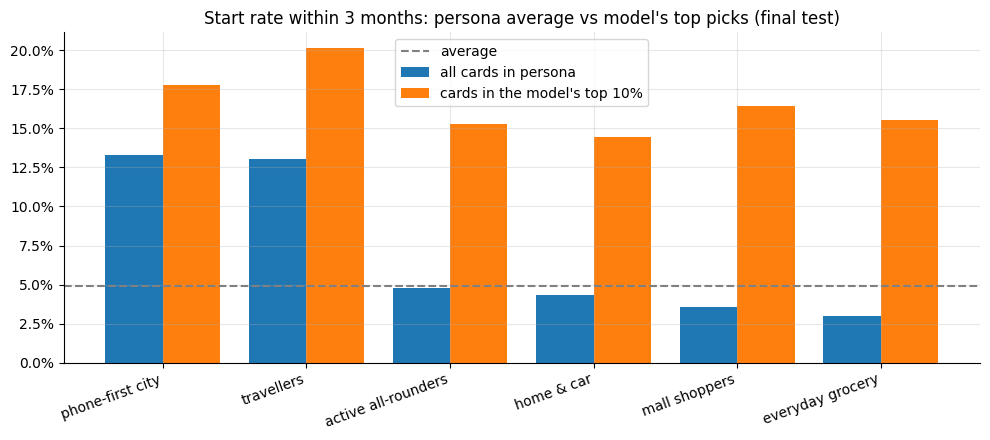

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(personas))
ax.bar(x - 0.2, personas.actual_start_pct, width=0.4, label="all cards in persona")
ax.bar(x + 0.2, personas.top10_start_pct, width=0.4, label="cards in the model's top 10%")
ax.axhline(yte.mean() * 100, color="grey", ls="--", label="average")
ax.set_xticks(x, personas.persona, rotation=20, ha="right")
ax.yaxis.set_major_formatter(pct)
ax.set_title("Start rate within 3 months: persona average vs model's top picks (final test)")
ax.legend()
plt.tight_layout()

In [11]:
# Export aggregated results for the dashboard (no card-level data)
import json

order = np.argsort(-p_cal)
cum = np.cumsum(yte[order]) / yte.sum()
gains = [{"contacted_pct": q, "starters_reached_pct": round(float(cum[max(int(len(cum) * q / 100) - 1, 0)]) * 100, 2)}
         for q in range(5, 101, 5)]
dashboard = {
    "final_test": {"period": MONTH_NAMES[FINAL_T], "cards": int(len(yte)), "start_rate": float(yte.mean()),
                   **{k: float(v) for k, v in final_metrics[final_metrics.version == "calibrated"].iloc[0].items()
                      if k != "version"}},
    "backtest": backtest.round(4).to_dict(orient="records"),
    "calibration_deciles": r.reset_index().round(4).to_dict(orient="records"),
    "gains": gains,
    "drivers": top.reset_index(names="feature").round(4).to_dict(orient="records"),
    "personas": personas.round(3).to_dict(orient="records"),
}
Path("results").mkdir(exist_ok=True)
(Path("results") / "readiness_model.json").write_text(json.dumps(dashboard, ensure_ascii=False, indent=2, default=float),
                                                      encoding="utf-8")
print("saved results/readiness_model.json")

saved results/readiness_model.json


## Verdict

**Stable on three later periods, each predicted only from the past**

| Test period | Start rate | Rule (wallet) AUC | Logistic AUC | LightGBM AUC | LightGBM lift top 10% |
|---|---|---|---|---|---|
| Oct 2025 | 6.2% | 0.615 | 0.722 | **0.736** | 3.2x |
| Jan 2026 | 5.2% | 0.616 | 0.727 | **0.742** | 3.3x |
| Apr 2026 | 4.9% | 0.629 | 0.739 | **0.757** | 3.5x |

- LightGBM beats logistic regression by +0.015-0.018 AUC and the one-line rule by ~0.12 in every period.
- **Tuning:** all 24 settings give AUC 0.735-0.739 in validation, so the model is robust to its settings; tuning adds little.
- **Calibration:** the raw model over-predicts (mean 6.0% vs actual 4.9%) because the start rate falls over time;
  after isotonic calibration on Jan 2026 the mean is 4.7% and deciles match (top decile predicted 16.3%, actual 17.4%).
  Ranking (AUC 0.756) is unchanged.
- **Reach:** contacting the top 20% of cards reaches about 54% of all starters (lift 2.7x).

**Drivers (SHAP):** evening activity, fast food, fuel / car, restaurants, any phone payment in store, public transport,
payments abroad, entertainment and money transfers push the score up; a high typical in-store amount pushes it down.

**Personas x model (Apr 2026):**

| Persona | Cards | Start rate | Model's top-10% cards inside it: start rate |
|---|---|---|---|
| phone-first city | 29k | 13.3% | 17.8% |
| travellers | 3k | 13.0% | 20.1% |
| active all-rounders | 64k | 4.8% | 15.3% |
| home & car | 29k | 4.3% | 14.5% |
| mall shoppers | 52k | 3.5% | 16.4% |
| everyday grocery | 88k | 3.0% | 15.6% |

Personas explain *who* customers are; the model adds *which cards* inside each persona are ready. Even in the
low-start personas (everyday grocery, mall shoppers) the model's top picks start at 15-16%, about 5x their persona
average: targeting by persona alone would miss them.

**Limitations:** synthetic data; the model predicts who is *likely* to start, not who can be *persuaded* (needs an A/B
pilot); cards that pay online with BLIK or another card look like "never online"; one person can hold several cards.
